In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline  

# Baseline Figures Comparison

In [3]:
title = "HEMT vs SIS"
legend_bbox = (1.0,1.0)

In [4]:
possible_physical_qubits = [3899, # HEMT-LP-mn
                            3961, # HEMT-LP-YBCO
                            3028, # SISv2-9w-mn
                            3687, # SISv2-21w-mn
                            4151, # SISv2-21w-YBCO
                           ]

In [5]:
# Experiment Name and Locations
exp_name_path = {
    "ff-fc-delft-hemt-lp_mn-kide": PROJ_ROOT_PATH / "notebooks" / "experiments" / "hemt",
    "ff-fc-delft-hemt-lp_ybco-kide": PROJ_ROOT_PATH / "notebooks" / "experiments" / "hemt",
    "ff-fc-delft-sisv2_9w_mn-kide": PROJ_ROOT_PATH / "notebooks" / "experiments" / "sisv2_mn",
    "ff-fc-delft-sisv2_21w_mn-kide": PROJ_ROOT_PATH / "notebooks" / "experiments" / "sisv2_mn",
    "ff-fc-delft-sisv2_9w_ybco-kide": PROJ_ROOT_PATH / "notebooks" / "experiments" / "sisv2_mn",
}


In [6]:
df_final = pd.DataFrame()

In [7]:
# Load Dataframes
rows_4K = []
for exp_name in exp_name_path.keys():
    # Get file path
    exp_dir = exp_name_path[exp_name]
    file_path = exp_dir / exp_name / f"{exp_name}.pkl"
    # Read dataframe
    df = pd.read_pickle(file_path)
    # Extract only the values for 4K
    rows_4K.append(df.loc["4K"])

df_4K = pd.DataFrame(rows_4K, index=exp_name_path.keys()).fillna(0)

# 1) Decide the plotting order of stacks (columns)
# Reorder columns: PASSIVE first
original_columns = df_4K.columns.tolist()
passive_cols = [col for col in df_4K.columns if col[1] == 'PASSIVE']
active_cols  = [col for col in df_4K.columns if col[1] != 'PASSIVE']
reordered_columns = passive_cols + active_cols

# Reorder df_plot accordingly
df_4K = df_4K[reordered_columns]
cols = list(df_4K.columns)

In [8]:
from library.utils import fontstyle, style_map

title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# Define fallbacks (only used if a stack tuple isn’t in style_map)
# fallback_colors = plt.cm.tab20.colors  # a nice, long qualitative palette
# fallback_hatches = ['/', '\\', 'x', '-', '+', 'o', 'O', '.', '*']  # repeats cyclically
fallback_color = 'white' 
fallback_hatch = '//'  

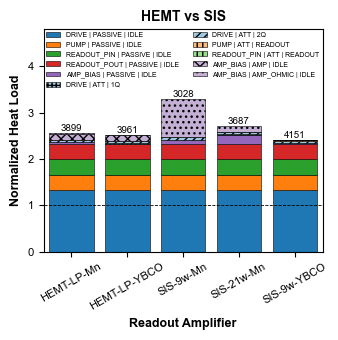

In [9]:
# 5) X positions and labels (temperature stages)
x = np.arange(len(df_4K.index))
xticklabels = ["HEMT-LP-Mn", "HEMT-LP-YBCO", "SIS-9w-Mn", "SIS-21w-Mn", "SIS-9w-YBCO"]

# 6) Create the figure/axes
# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(figsize=(3.5, 3.5))

# 7) Build the stacked bars
bottom = np.zeros(len(x), dtype=float)

for i, col in enumerate(cols):
    values = df_4K[col].astype(float).values

    # pull style from style_map if present, else fallback
    style = style_map.get(col, {})
    color = style.get('color', fallback_color)
    hatch = style.get('hatch', fallback_hatch)

    # readable label in legend
    label = f"{col[0]} | {col[1]} | {col[2]}"

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=label,
        color=color,
        edgecolor='black',
        linewidth=0.4
    )
    # apply hatch to each rectangle
    for b in bars:
        b.set_hatch(hatch)

    bottom += values  # update stack baseline

# Display no. of supported qubits on top of the bar
totals = df_4K .sum(axis=1)  # Sum over column. Get bar height
for i, total in enumerate(totals):
    ax.text(i, total, f'{possible_physical_qubits[i]}', ha='center', va='bottom', fontproperties=text_font)

# Draw horizantal line at y=1
ax.axhline(y=1, color='k', linestyle='--',linewidth=0.6)

# 8) Axis cosmetics
# Set titles 
ax.set_title(title, fontproperties=title_font)
ax.set_xlabel("Readout Amplifier", fontproperties=axis_label_font)
ax.set_ylabel("Normalized Heat Load", fontproperties=axis_label_font)
ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontproperties=tick_label_font, rotation=30)
for label in ax.get_yticklabels() :
    label.set_fontproperties(tick_label_font)
ax.set_ylim(0, max(totals) + 1.5) # Set max y-value to be slightly higher than the tallest bar

# 9) Legend: shrink and place outside
ax.legend(ncol=2, 
          bbox_to_anchor=(0,1),
          loc='upper left',
          prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.margins(x=0.02)
plt.tight_layout()
plt.savefig(f"./hemt-sis.png",dpi=600)
plt.show()